# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [4]:
import pandas as pd

df = pd.read_csv("genes_freq_by_aa.csv", index_col='Unnamed: 0')

df

,M,N,K,Y,F,T,C,V,A,S,L,G,Q,H,I,E,P,D,R,W
oxa23,11,19,22,7,12,14,2,21,16,14,27,18,18,4,18,20,9,8,7,6
kpc,4,10,10,10,9,21,3,19,44,21,33,26,10,1,8,12,13,14,18,6
vim,3,9,6,9,4,14,1,30,32,23,25,24,5,11,11,18,15,13,10,3
ndm,12,11,9,4,9,17,2,16,41,14,22,25,12,10,14,7,15,17,9,4
tet,12,31,42,32,20,42,11,41,26,45,70,37,27,12,53,52,27,27,28,4


In [43]:
# Definir função que recebe obj composto unidimensional e retorna medidas de tendencia central

def medidas_tendendia_central(dataframe: pd.DataFrame, obj_composto: list | tuple):

    for aminoacido in obj_composto:

        # Deixa upper case
        aminoacido = aminoacido.upper()

        # Se não estiver na lista, não é aminoácido
        if aminoacido not in ["M", "N", "K", "Y", "F", "T",	"C", "V", "A", "S",	"L", "G", "Q", "H", "I", "E", "P", "D", "R", "W"]:
            print(f"{aminoacido} não é um aminoácido!")
            break

        # Defini uma série com o numero do aminoácido x para cada gene
        serie = dataframe[aminoacido]

        print(f"{aminoacido}:")
        print(f"Média = {serie.mean()}")
        print(f"Mediana = {serie.median()}")

        moda = serie.mode()
        if len(moda) == 1:
            print(f"Moda = {list(moda)}")
        else:
            print(f"Moda de {aminoacido}: múltiplos valores {list(moda)}")
        print()


In [44]:
medidas_tendendia_central(dataframe=df, obj_composto=['A', 'c'])

A:
Média = 31.8
Mediana = 32.0
Moda de A: múltiplos valores [16, 26, 32, 41, 44]

C:
Média = 3.8
Mediana = 2.0
Moda = [2]



In [45]:
# Qual a média, mediana e moda da Serina nos genes analisados
medidas_tendendia_central(dataframe=df, obj_composto=['S'])

S:
Média = 23.4
Mediana = 21.0
Moda = [14]



In [113]:
# Qual a média, mediana e moda da Serina no terceiro gene
print("Média: ", df.loc['vim'].mean())
print("Mediana: ", df.loc['vim'].median())
print("Moda: ", df.loc['vim'].mode())

Média:  13.3
Mediana:  11.0
Moda:  0     3
1     9
2    11
Name: vim, dtype: int64


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [53]:
def amplitude(dataframe: pd.DataFrame, obj_composto: list | tuple):

    for aminoacido in obj_composto:

        # Deixa upper case
        aminoacido = aminoacido.upper()

        # Se não estiver na lista, não é aminoácido
        if aminoacido not in dataframe.columns:
            print(f"{aminoacido} não é um aminoácido!")
            continue

        serie = dataframe[aminoacido]

        amp = serie.max() - serie.min()

        print(f"Amplitude de {aminoacido}: {amp}")
        

In [54]:
amplitude(dataframe=df, obj_composto=['I'])

Amplitude de I: 45


In [108]:
# Amplitude do último gene
max(df.iloc[-1]) - min(df.iloc[-1])


66

## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [79]:
def quartis(dataframe: pd.DataFrame, obj_composto: list | tuple):

    for aminoacido in obj_composto:

        # Deixa upper case
        aminoacido = aminoacido.upper()

        # Se não estiver na lista, não é aminoácido
        if aminoacido not in dataframe.columns:
            print(f"{aminoacido} não é um aminoácido!")
            continue

        serie = dataframe[aminoacido]

        serie_descrita = serie.describe()

        print(f"Quartis do aminoácido {aminoacido}:")
        print(f"Q1 = {serie_descrita['25%']}")
        print(f"Q1 = {serie_descrita['50%']}")
        print(f"Q1 = {serie_descrita['75%']}")

In [80]:
quartis(dataframe=df, obj_composto=['M'])

Quartis do aminoácido M:
Q1 = 4.0
Q1 = 11.0
Q1 = 12.0


In [105]:
# Quartis no primeiro gene
primeiro_describe = df.iloc[0].describe()

print(f"Q1 = {primeiro_describe['25%']}")
print(f"Q1 = {primeiro_describe['50%']}")
print(f"Q1 = {primeiro_describe['75%']}")

Q1 = 7.75
Q1 = 14.0
Q1 = 18.25


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [84]:
def interquartil(dataframe: pd.DataFrame, obj_composto: list | tuple):

    for aminoacido in obj_composto:

        # Deixa upper case
        aminoacido = aminoacido.upper()

        # Se não estiver na lista, não é aminoácido
        if aminoacido not in dataframe.columns:
            print(f"{aminoacido} não é um aminoácido!")
            continue

        serie = dataframe[aminoacido]

        serie_descrita = serie.describe()

        interquartil = serie_descrita['75%'] - serie_descrita['25%']

        print(f"Intervalo interquaril do aminoácido '{aminoacido}': {interquartil}")

In [85]:
interquartil(dataframe=df, obj_composto=['E'])

Intervalo interquaril do aminoácido 'E': 8.0


In [104]:
# Intervalo interquartil do penúltimo gene

penultimo_describe = df.iloc[-2].describe()

inter = penultimo_describe['75%'] - penultimo_describe['25%']

print(f"Interquartil do penúltimo gene: {inter}")

Interquartil do penúltimo gene: 7.25


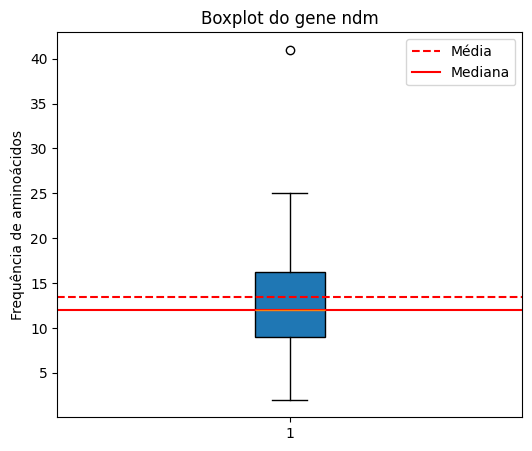

In [153]:
### BOX PLOT
import matplotlib.pyplot as plt

serie = df.iloc[-2]

plt.figure(figsize=(6,5))

plt.boxplot(serie, vert=True, patch_artist=True)

# Medidas de tendência central
media = serie.mean()
mediana = serie.median()

# Linhas
plt.axhline(media, linestyle='--', label='Média', color='red')
plt.axhline(mediana, linestyle='-', label='Mediana', color='red')

plt.title(f'Boxplot do gene {df.index[-2]}')
plt.ylabel('Frequência de aminoácidos')

plt.legend()
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [87]:
def variancia(dataframe: pd.DataFrame, obj_composto: list | tuple):

    for aminoacido in obj_composto:

        # Deixa upper case
        aminoacido = aminoacido.upper()

        # Se não estiver na lista, não é aminoácido
        if aminoacido not in dataframe.columns:
            print(f"{aminoacido} não é um aminoácido!")
            continue

        serie = dataframe[aminoacido]

        # Variância amostral não viciada (ddof=1)
        variancia = serie.var(ddof=1)

        print(f"Variância amostral de '{aminoacido}': {variancia}")

In [88]:
variancia(dataframe=df, obj_composto=['P'])

Variância amostral de 'P': 45.2


In [97]:
# Desvio padrão do ultimo gene

var = df.iloc[2].var(ddof=1)
print(f"Variancia do último gene: {var}")

Variancia do último gene: 85.8


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [92]:
def desvio_padrao(dataframe: pd.DataFrame, obj_composto: list | tuple):

    for aminoacido in obj_composto:

        # Deixa upper case
        aminoacido = aminoacido.upper()

        # Se não estiver na lista, não é aminoácido
        if aminoacido not in dataframe.columns:
            print(f"{aminoacido} não é um aminoácido!")
            continue

        serie = dataframe[aminoacido]

        # Desvio padrão amostral (ddof=1)
        desvio = serie.std(ddof=1)

        print(f"Desvio padrão de '{aminoacido}': {desvio}")

In [93]:
desvio_padrao(df, ['W'])

Desvio padrão de 'W': 1.3416407864998738


In [95]:
# Desvio padrão do ultimo gene

desvio_gene = df.iloc[-1].std(ddof=1)
print(f"Desvio padrão do último gene: {desvio_gene}")

Desvio padrão do último gene: 16.314265633423243


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [114]:
def coeficiente_variacao(dataframe: pd.DataFrame, obj_composto: list | tuple):

    for aminoacido in obj_composto:

        # Deixa upper case
        aminoacido = aminoacido.upper()

        # Se não estiver na lista, não é aminoácido
        if aminoacido not in dataframe.columns:
            print(f"{aminoacido} não é um aminoácido!")
            continue

        serie = dataframe[aminoacido]

        media = serie.mean()
        desvio = serie.std(ddof=1)

        # Evitar divisão por zero
        if media == 0:
            print(f"Coeficiente de variação de '{aminoacido}': indefinido (média = 0)")
            continue

        cv = (desvio / media) * 100

        print(f"Coeficiente de variação de '{aminoacido}': {cv:.2f}%")

In [116]:
coeficiente_variacao(df, ['L'])

Coeficiente de variação de 'L': 55.81%


In [118]:
# Coeficiente de variação do gene de index -1
media = df.iloc[-1].mean()
desvio = df.iloc[-1].std(ddof=1)

cv = (desvio / media) * 100

print(f"Coeficiente de variação: {cv:.2f}%")

Coeficiente de variação: 51.06%


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [140]:
def medidas_resumo(dataframe: pd.DataFrame, obj_composto: list | tuple):

    for aminoacido in obj_composto:

        # Deixa upper case
        aminoacido = aminoacido.upper()

        # Se não estiver na lista, não é aminoácido
        if aminoacido not in dataframe.columns:
            print(f"{aminoacido} não é um aminoácido!")
            continue

        serie = dataframe[aminoacido]

        serie_descrita = serie.describe()

        dict_resumo = {
            "count": serie_descrita["count"],
            "mean": serie_descrita["mean"],
            "std": serie_descrita["std"],
            "min": serie_descrita["min"],
            "25%": serie_descrita["25%"],
            "50%": serie_descrita["50%"],
            "75%": serie_descrita["75%"],
            "max": serie_descrita["max"]
        }

        display(dict_resumo)


In [141]:
medidas_resumo(df, ['M'])

{'count': np.float64(5.0),
 'mean': np.float64(8.4),
 'std': np.float64(4.505552130427524),
 'min': np.float64(3.0),
 '25%': np.float64(4.0),
 '50%': np.float64(11.0),
 '75%': np.float64(12.0),
 'max': np.float64(12.0)}

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [144]:
def maior_cv_gene(dataframe: pd.DataFrame):

    cvs = {}

    for gene in dataframe.index:

        serie = dataframe.loc[gene]

        media = serie.mean()
        desvio = serie.std(ddof=1)

        if media == 0:
            cvs[gene] = 0
        else:
            cvs[gene] = (desvio / media) * 100

    # pega o maior
    gene_max = max(cvs, key=cvs.get)

    print("CV por gene:")
    for g, v in cvs.items():
        print(f"{g}: {v:.2f}%")

    print(f"\nGene com maior CV: {gene_max}")

In [145]:
maior_cv_gene(df)

CV por gene:
oxa23: 49.65%
kpc: 72.36%
vim: 69.65%
ndm: 64.33%
tet: 51.06%

Gene com maior CV: kpc


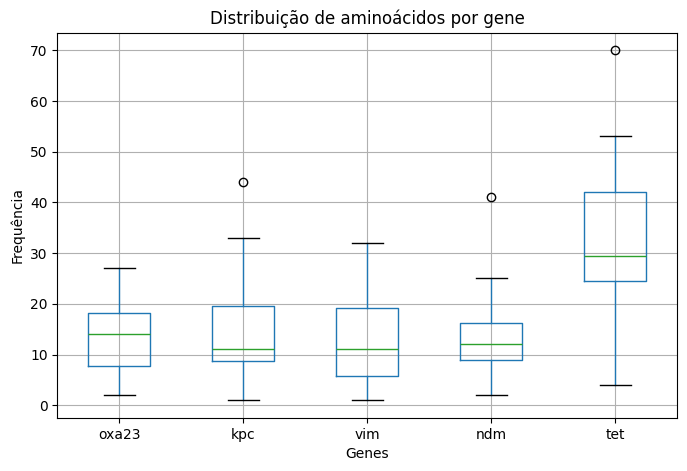

In [150]:
# BOX PLOT dos genes
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.T.boxplot()
plt.title("Distribuição de aminoácidos por gene")
plt.xlabel("Genes")
plt.ylabel("Frequência")

plt.show()

# Os dados concordam? Pq?
O gene kpc apresenta o maior coeficiente de variação, indicando maior variabilidade relativa na frequência de aminoácidos em relação à sua média.

No entanto, o boxplot mostra que o gene tet possui maior dispersão absoluta, com maior amplitude e presença de valores extremos. Essa diferença ocorre porque o coeficiente de variação normaliza a dispersão pela média, enquanto o boxplot representa a distribuição dos valores de forma absoluta. Portanto, os resultados não concordam completamente, pois medem aspectos diferentes da variabilidade.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [154]:
def maior_cv_aminoacido(dataframe: pd.DataFrame):

    cvs = {}

    for aa in dataframe.columns:

        serie = dataframe[aa]

        media = serie.mean()
        desvio = serie.std(ddof=1)

        if media == 0:
            cvs[aa] = 0
        else:
            cvs[aa] = (desvio / media) * 100

    # pega o maior
    aa_max = max(cvs, key=cvs.get)

    print("CV por aminoácido:")
    for g, v in cvs.items():
        print(f"{g}: {v:.2f}%")

    print(f"\nGene com maior CV: {aa_max}")

In [156]:
maior_cv_aminoacido(df)

CV por aminoácido:
M: 53.64%
N: 57.96%
K: 83.37%
Y: 90.27%
F: 54.54%
T: 54.44%
C: 107.54%
V: 40.01%
A: 35.74%
S: 54.44%
L: 55.81%
G: 26.51%
Q: 58.64%
H: 63.51%
I: 88.35%
E: 80.92%
P: 42.55%
D: 44.62%
R: 60.26%
W: 29.17%

Gene com maior CV: C


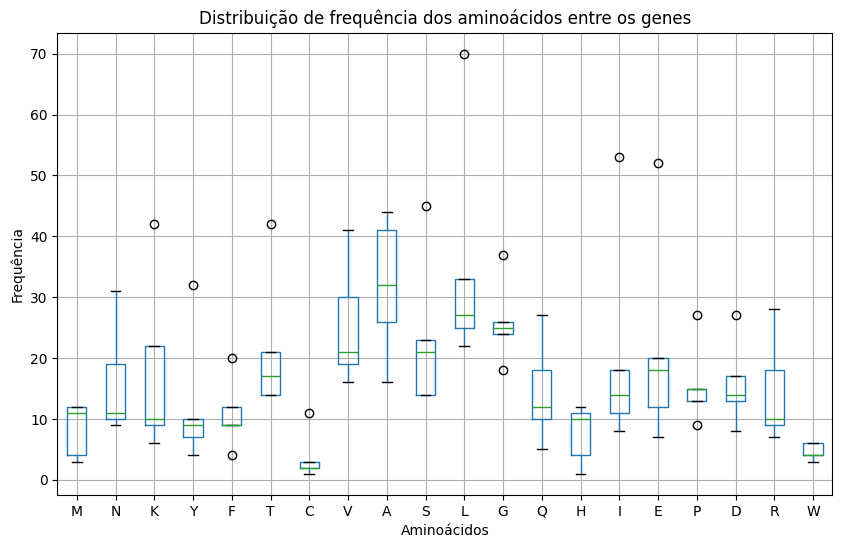

In [158]:
plt.figure(figsize=(10,6))

df.boxplot()

plt.title("Distribuição de frequência dos aminoácidos entre os genes")
plt.xlabel("Aminoácidos")
plt.ylabel("Frequência")

plt.xticks(rotation=0)
plt.show()

# Os dados concordam?
O aminoácido C (Cisteína) apresentou o maior coeficiente de variação, indicando alta variabilidade relativa entre os genes.
No entanto, o boxplot não mostra grande dispersão absoluta para esse aminoácido, apresentando valores baixos e pouco espalhados.
Essa diferença ocorre porque o coeficiente de variação é influenciado pela média, e valores baixos podem inflar o CV mesmo com pequena variação absoluta.
Portanto, os resultados não concordam completamente, pois o CV mede variabilidade relativa, enquanto o boxplot representa a distribuição absoluta dos dados.